In [1]:
import warnings
warnings.filterwarnings(action='ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

누락값(결측치) 처리하기

분석하려는 데이터에 누락값이 없으면 좋겠지만 누락값은 대부분의 데이터에 존재하고 깔끔한 데이터를 위해서 누락값을 처리하는 것은 매우 중요하다.  
누락값은 pandas에서는 NaN으로 표기되고 누락값 자체를 사용해보려면 numpy 라이브러리가 필요하다.

과거 numpy에서는 대소문자 구별 없이 NaN, NAN, nan을 모두 지원했었지만, 코드의 일관성을 위해 대문자 형태인 NaN과 NAN은 공식적으로 지원이 중단되었고 현재는 소문자인 nan만 사용이 가능하다.

In [2]:
# 누락값을 사용하기 위해서 numpy에서 누락값을 import 한다.
from numpy import nan

In [3]:
# 누락값은 0, ''과 같은 값과는 다른 개념으로 데이터 자체가 없다는 것을 의미한다. => None, null
print(nan == True)
print(nan == False)
print(nan == 0)
print(nan == '')
print(nan == nan) # 누락값은 값 자체가 없기 때문에 자기 자신과 비교해도 False가 출력된다.

False
False
False
False
False


누락값 여부를 확인하는 메소드 isnull(), isna() 메소드가 있고 누락값은 True, 누락값이 아니면 False를 리턴한다.

In [4]:
print(pd.isnull(nan))
print(pd.isna(nan))
print(pd.isnull(0))
print(pd.isna(''))

True
True
False
False


isnull(), isna() 메소드와 반대로 누락값은 False, 누락값이 아니면 True를 리턴하는 notnull(), notna() 메소드도 있다.

In [5]:
print(pd.notnull(nan))
print(pd.notna(nan))
print(pd.notnull(0))
print(pd.notna(''))

False
False
True
True


누락값 확인하기

In [6]:
# Cases_* => 국가별 발병자 수, Deaths_* => 국가별 사망자 수
ebola = pd.read_csv('./data/country_timeseries.csv')
ebola

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone,Cases_Nigeria,Cases_Senegal,Cases_UnitedStates,Cases_Spain,Cases_Mali,Deaths_Guinea,Deaths_Liberia,Deaths_SierraLeone,Deaths_Nigeria,Deaths_Senegal,Deaths_UnitedStates,Deaths_Spain,Deaths_Mali
0,1/5/2015,289,2776.0,NaN,10030.0,NaN,NaN,NaN,NaN,NaN,1786.0,NaN,2977.0,NaN,NaN,NaN,NaN,NaN
1,1/4/2015,288,2775.0,NaN,9780.0,NaN,NaN,NaN,NaN,NaN,1781.0,NaN,2943.0,NaN,NaN,NaN,NaN,NaN
2,1/3/2015,287,2769.0,8166.0,9722.0,NaN,NaN,NaN,NaN,NaN,1767.0,3496.0,2915.0,NaN,NaN,NaN,NaN,NaN
3,1/2/2015,286,NaN,8157.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3496.0,NaN,NaN,NaN,NaN,NaN,NaN
4,12/31/2014,284,2730.0,8115.0,9633.0,NaN,NaN,NaN,NaN,NaN,1739.0,3471.0,2827.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,3/27/2014,5,103.0,8.0,6.0,NaN,NaN,NaN,NaN,NaN,66.0,6.0,5.0,NaN,NaN,NaN,NaN,NaN
118,3/26/2014,4,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,3/25/2014,3,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,3/24/2014,2,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


numpy의 count_nonzero() 메소드는 0 또는 False가 아닌 데이터의 개수를 센다. => 문자가 입력되면 오동작한다.

In [7]:
print(np.count_nonzero([False, 0, True, 1, 100]))
print(np.count_nonzero(ebola.isnull())) # ebola 데이터프레임의 전체 누락값 개수
print(np.count_nonzero(ebola['Cases_Guinea'].isnull())) # ebola 데이터프레임의 Cases_Guinea 열의 누락값 개수
print(np.count_nonzero(ebola.get('Cases_Liberia').isnull())) # ebola 데이터프레임의 Cases_Liberia 열의 누락값 개수
print(np.count_nonzero(ebola.Cases_SierraLeone.isnull())) # ebola 데이터프레임의 Cases_SierraLeone 열의 누락값 개수

3
1214
29
39
35


count() 메소드는 열 인덱스 별로 누락값이 아닌 데이터의 개수를 센다.

In [8]:
print(ebola.count())
print(ebola.shape)
print(ebola.shape[0])
# 전체 대이터의 개수에서 누락값이 아닌 데이터의 개수를 빼면 누락값의 개수가 된다.
print(ebola.shape[0] - ebola.count())

Date                   122
Day                    122
Cases_Guinea            93
Cases_Liberia           83
Cases_SierraLeone       87
Cases_Nigeria           38
Cases_Senegal           25
Cases_UnitedStates      18
Cases_Spain             16
Cases_Mali              12
Deaths_Guinea           92
Deaths_Liberia          81
Deaths_SierraLeone      87
Deaths_Nigeria          38
Deaths_Senegal          22
Deaths_UnitedStates     18
Deaths_Spain            16
Deaths_Mali             12
dtype: int64
(122, 18)
122
Date                     0
Day                      0
Cases_Guinea            29
Cases_Liberia           39
Cases_SierraLeone       35
Cases_Nigeria           84
Cases_Senegal           97
Cases_UnitedStates     104
Cases_Spain            106
Cases_Mali             110
Deaths_Guinea           30
Deaths_Liberia          41
Deaths_SierraLeone      35
Deaths_Nigeria          84
Deaths_Senegal         100
Deaths_UnitedStates    104
Deaths_Spain           106
Deaths_Mali            110
d

value_counts() 메소드로 시리즈에 저장된 데이터의 빈도수를 얻어올 수 있다.

In [9]:
print(type(ebola.Cases_Guinea))
# print(ebola.Cases_Guinea.value_counts())
print(ebola.Cases_Guinea.value_counts(dropna=True))

<class 'pandas.Series'>
Cases_Guinea
86.0      3
495.0     2
390.0     2
112.0     2
2776.0    1
         ..
143.0     1
127.0     1
122.0     1
103.0     1
49.0      1
Name: count, Length: 88, dtype: int64


value_counts() 메소드는 dropna 옵션의 기본값이 True로 설정되어 있어서 기본적으로 누락값을 무시하고 데이터의 출현 빈도수를 얻어온다.  
누락값을 포함한 데이터의 빈도수를 얻어오려면 dropna 옵션값을 False로 지정하면 된다.

In [10]:
print(ebola.Cases_Guinea.value_counts(dropna=False))

Cases_Guinea
NaN      29
86.0      3
495.0     2
390.0     2
112.0     2
         ..
143.0     1
127.0     1
122.0     1
103.0     1
49.0      1
Name: count, Length: 89, dtype: int64


missingno 라이브러리로 누락값의 분포 확인하기  
missingno 라이브러리를 사용하기 위해서 설치하고 import 시킨다.

In [11]:
# !pip install missingno
import missingno as msno

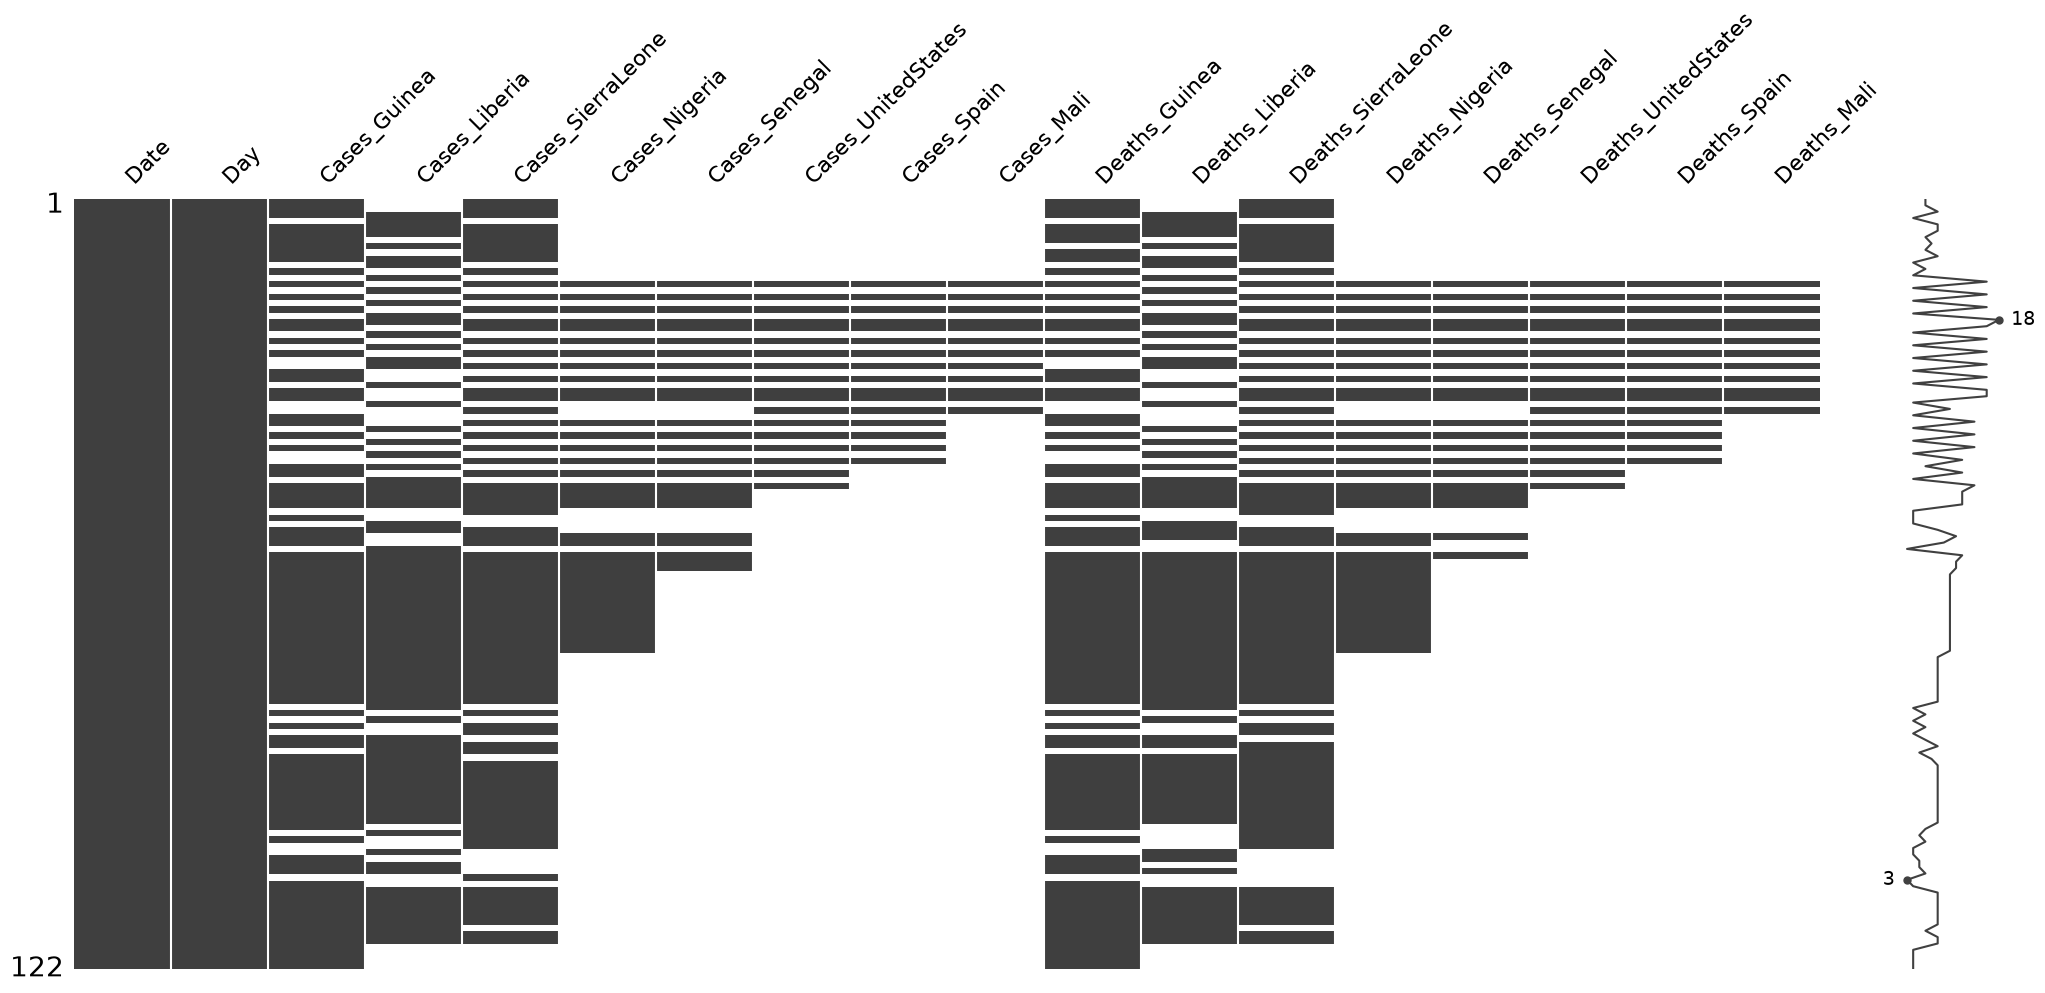

In [12]:
msno.matrix(ebola)
plt.show()

누락값 처리하기

In [13]:
ebola_na = ebola.iloc[:10, :5]
ebola_na

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone
0,1/5/2015,289,2776.0,NaN,10030.0
1,1/4/2015,288,2775.0,NaN,9780.0
2,1/3/2015,287,2769.0,8166.0,9722.0
3,1/2/2015,286,NaN,8157.0,NaN
4,12/31/2014,284,2730.0,8115.0,9633.0
5,12/28/2014,281,2706.0,8018.0,9446.0
6,12/27/2014,280,2695.0,NaN,9409.0
7,12/24/2014,277,2630.0,7977.0,9203.0
8,12/21/2014,273,2597.0,NaN,9004.0
9,12/20/2014,272,2571.0,7862.0,8939.0


dropna() 메소드는 누락값이 1개 이상 포함된 행을 제거한다.

In [14]:
ebola_na.dropna()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone
2,1/3/2015,287,2769.0,8166.0,9722.0
4,12/31/2014,284,2730.0,8115.0,9633.0
5,12/28/2014,281,2706.0,8018.0,9446.0
7,12/24/2014,277,2630.0,7977.0,9203.0
9,12/20/2014,272,2571.0,7862.0,8939.0


fillna() 메소드는 누락값을 메소드의 인수로 지정한 값으로 변경한다.

In [15]:
ebola_na.fillna(0)

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone
0,1/5/2015,289,2776.0,0.0,10030.0
1,1/4/2015,288,2775.0,0.0,9780.0
2,1/3/2015,287,2769.0,8166.0,9722.0
3,1/2/2015,286,0.0,8157.0,0.0
4,12/31/2014,284,2730.0,8115.0,9633.0
5,12/28/2014,281,2706.0,8018.0,9446.0
6,12/27/2014,280,2695.0,0.0,9409.0
7,12/24/2014,277,2630.0,7977.0,9203.0
8,12/21/2014,273,2597.0,0.0,9004.0
9,12/20/2014,272,2571.0,7862.0,8939.0


ffill() 메소드는 누락값을 누락값 바로 전 값으로 변경한다.

In [16]:
ebola_na.ffill()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone
0,1/5/2015,289,2776.0,NaN,10030.0
1,1/4/2015,288,2775.0,NaN,9780.0
2,1/3/2015,287,2769.0,8166.0,9722.0
3,1/2/2015,286,2769.0,8157.0,9722.0
4,12/31/2014,284,2730.0,8115.0,9633.0
5,12/28/2014,281,2706.0,8018.0,9446.0
6,12/27/2014,280,2695.0,8018.0,9409.0
7,12/24/2014,277,2630.0,7977.0,9203.0
8,12/21/2014,273,2597.0,7977.0,9004.0
9,12/20/2014,272,2571.0,7862.0,8939.0


bfill() 메소드는 누락값을 누락값 바로 다음 값으로 변경한다.

In [17]:
ebola_na.bfill()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone
0,1/5/2015,289,2776.0,8166.0,10030.0
1,1/4/2015,288,2775.0,8166.0,9780.0
2,1/3/2015,287,2769.0,8166.0,9722.0
3,1/2/2015,286,2730.0,8157.0,9633.0
4,12/31/2014,284,2730.0,8115.0,9633.0
5,12/28/2014,281,2706.0,8018.0,9446.0
6,12/27/2014,280,2695.0,7977.0,9409.0
7,12/24/2014,277,2630.0,7977.0,9203.0
8,12/21/2014,273,2597.0,7862.0,9004.0
9,12/20/2014,272,2571.0,7862.0,8939.0


interpolate() 메소드는 누락값 바로 전 값과 바로 다음 값의 평균으로 변경한다.  
pandas 버전이 3.x 버전으로 변경되면서 interpolate() 메소드를 실행하려는 데이터프레임에 문자열(str) 자료형을 가지는 열이 존재하면 에러가 발생된다.

In [18]:
# Date 열의 자료형이 str이므로 to_datetime() 메소드로 날짜/시간 데이터로 변경한 후 실행한다
ebola_na['Date'] = pd.to_datetime(ebola_na['Date'])
ebola_na.interpolate()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone
0,2015-01-05,289,2776.0,NaN,10030.0
1,2015-01-04,288,2775.0,NaN,9780.0
2,2015-01-03,287,2769.0,8166.0,9722.0
3,2015-01-02,286,2749.5,8157.0,9677.5
4,2014-12-31,284,2730.0,8115.0,9633.0
5,2014-12-28,281,2706.0,8018.0,9446.0
6,2014-12-27,280,2695.0,7997.5,9409.0
7,2014-12-24,277,2630.0,7977.0,9203.0
8,2014-12-21,273,2597.0,7919.5,9004.0
9,2014-12-20,272,2571.0,7862.0,8939.0


누락값이 하나라도 있으면 연산자를 사용한 계산 결과도 누락값이 된다.

In [19]:
ebola_na['Cases_Total'] = ebola_na.Cases_Guinea + ebola_na.Cases_Liberia + ebola_na.Cases_SierraLeone
ebola_na

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone,Cases_Total
0,2015-01-05,289,2776.0,NaN,10030.0,NaN
1,2015-01-04,288,2775.0,NaN,9780.0,NaN
2,2015-01-03,287,2769.0,8166.0,9722.0,20657.0
3,2015-01-02,286,NaN,8157.0,NaN,NaN
4,2014-12-31,284,2730.0,8115.0,9633.0,20478.0
5,2014-12-28,281,2706.0,8018.0,9446.0,20170.0
6,2014-12-27,280,2695.0,NaN,9409.0,NaN
7,2014-12-24,277,2630.0,7977.0,9203.0,19810.0
8,2014-12-21,273,2597.0,NaN,9004.0,NaN
9,2014-12-20,272,2571.0,7862.0,8939.0,19372.0


기초 통계를 계산하는 메소드들은 skipna 옵션이 True가 기본값으로 설정되어 있어서 누락값을 무시하고 메소드가 실행된다.

In [20]:
print(ebola_na.Cases_Guinea.sum()) # ebola_na.Cases_Guinea.sum(skipna=True)
print(ebola_na.Cases_Guinea.sum(skipna=False))
print(ebola_na.Cases_Guinea.mean())
print(ebola_na.Cases_Guinea.max())
print(ebola_na.Cases_Guinea.min())
print(ebola_na.Cases_Guinea.var())
print(ebola_na.Cases_Guinea.std())

24249.0
nan
2694.3333333333335
2776.0
2571.0
6122.999999999999
78.24960063795852


count() 메소드는 skipna 옵션이 제공되지 않는다.

In [21]:
print(ebola_na.Cases_Guinea.count())
# print(ebola_na.Cases_Guinea.count(skipna=False)) # 에러

9
